In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from src.features import FEATURE_COLUMNS

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

In [2]:
df = pd.read_csv("../data/processed/customer_features.csv")
X = df[FEATURE_COLUMNS].copy()
print(f"Customers: {len(X):,}, Features: {X.shape[1]}")
X.head()

Customers: 4,327, Features: 8


,Recency,Frequency,Monetary,AvgBasketValue,AvgItemsPerBasket,UniqueProducts,CancellationRate,CustomerLifespanDays
0,113,1.0,97.91,97.910000,21.000000,2,0.0,0
1,75,10.0,531.00,53.100000,13.700000,17,0.0,260
2,23,6.0,396.85,66.141667,12.666667,7,0.0,335
3,58,9.0,396.29,44.032222,12.666667,15,0.0,256
4,22,16.0,774.23,48.389375,14.687500,27,0.0,303


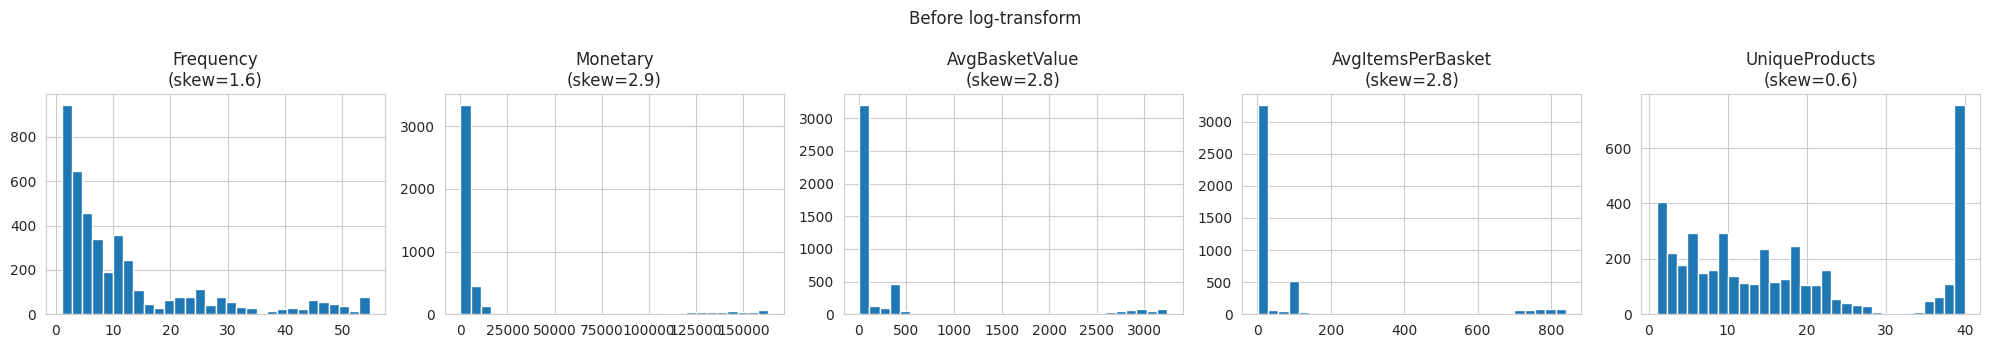

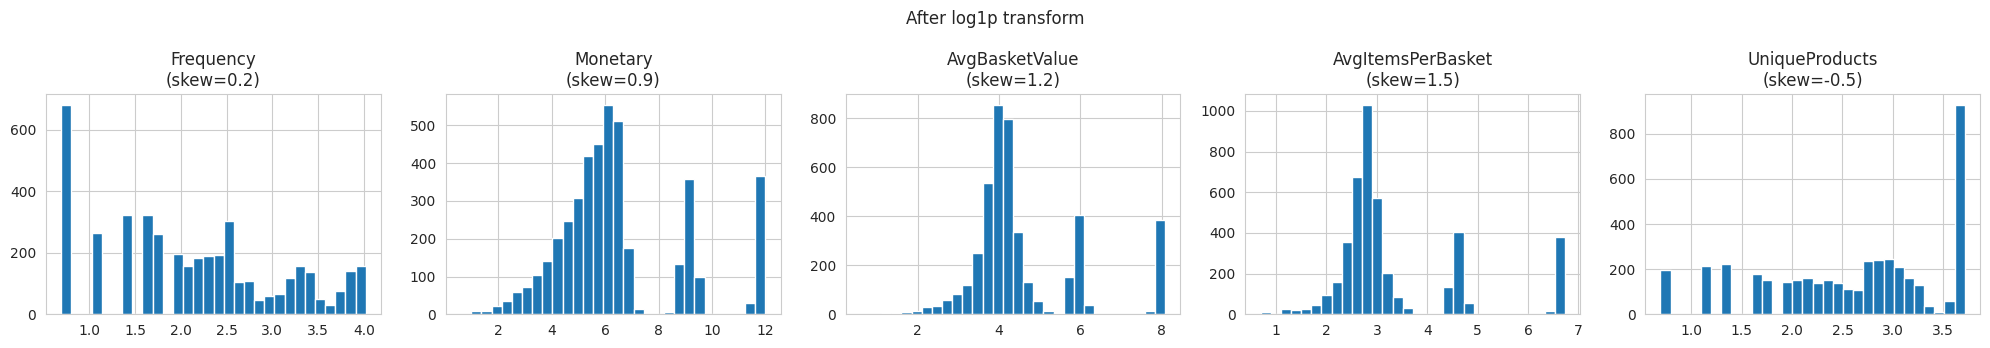

In [3]:
skewed_cols = ["Frequency", "Monetary", "AvgBasketValue", "AvgItemsPerBasket", "UniqueProducts"]

fig, axes = plt.subplots(1, len(skewed_cols), figsize=(20, 3.5))
for ax, col in zip(axes, skewed_cols):
    ax.hist(X[col], bins=30)
    ax.set_title(f"{col}\n(skew={X[col].skew():.1f})")
plt.suptitle("Before log-transform")
plt.tight_layout()
plt.savefig("../reports/figures/03_before_log_transform.png", dpi=120)
plt.show()

for col in skewed_cols:
    X[col] = np.log1p(X[col])

fig, axes = plt.subplots(1, len(skewed_cols), figsize=(20, 3.5))
for ax, col in zip(axes, skewed_cols):
    ax.hist(X[col], bins=30)
    ax.set_title(f"{col}\n(skew={X[col].skew():.1f})")
plt.suptitle("After log1p transform")
plt.tight_layout()
plt.savefig("../reports/figures/03_after_log_transform.png", dpi=120)
plt.show()

In [4]:
# X now holds log-transformed values for the skewed columns.
# Save this transformed frame so scaling below (and every notebook
# after it) operates on the log-transformed features, not raw ones.
X.to_csv("../data/processed/customer_features_log.csv", index=False)

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[ 0.52993668, -1.45602627, -0.78363946,  0.01901739, -0.18044857,
        -1.70304423, -0.32911111, -1.82341714],
       [ 0.07696068,  0.28909938, -0.07224597, -0.42333487, -0.49490075,
         0.33289717, -0.32911111,  0.4064318 ],
       [-0.5429012 , -0.17359117, -0.1951088 , -0.26500065, -0.55174596,
        -0.58854705, -0.32911111,  1.04965746],
       [-0.12568647,  0.19153174, -0.19570439, -0.55783163, -0.55174596,
         0.1990626 , -0.32911111,  0.37212643],
       [-0.55482162,  0.73472811,  0.0869587 , -0.49012205, -0.44419414,
         0.83494313, -0.32911111,  0.77521451]])

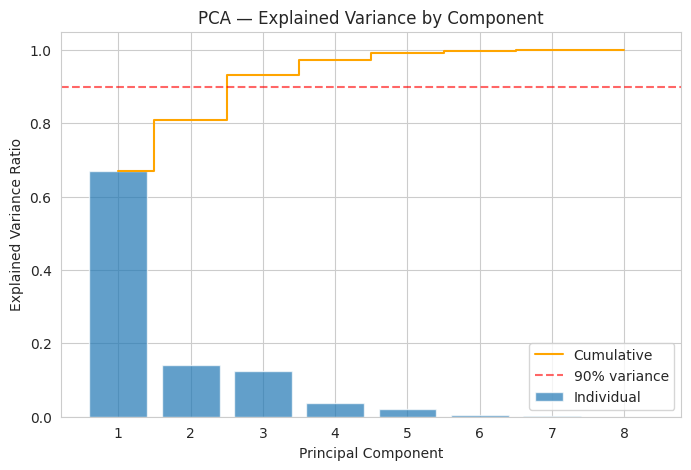

Components needed for 90% variance: 3 (out of 8 original features)


In [6]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1), pca_full.explained_variance_ratio_, alpha=0.7, label="Individual")
plt.step(range(1, len(cumulative_var) + 1), cumulative_var, where="mid", color="orange", label="Cumulative")
plt.axhline(y=0.90, color="red", linestyle="--", alpha=0.6, label="90% variance")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.legend()
plt.title("PCA — Explained Variance by Component")
plt.savefig("../reports/figures/03_pca_variance.png", dpi=120)
plt.show()

n_components_90 = int(np.argmax(cumulative_var >= 0.90) + 1)
print(f"Components needed for 90% variance: {n_components_90} (out of {X.shape[1]} original features)")

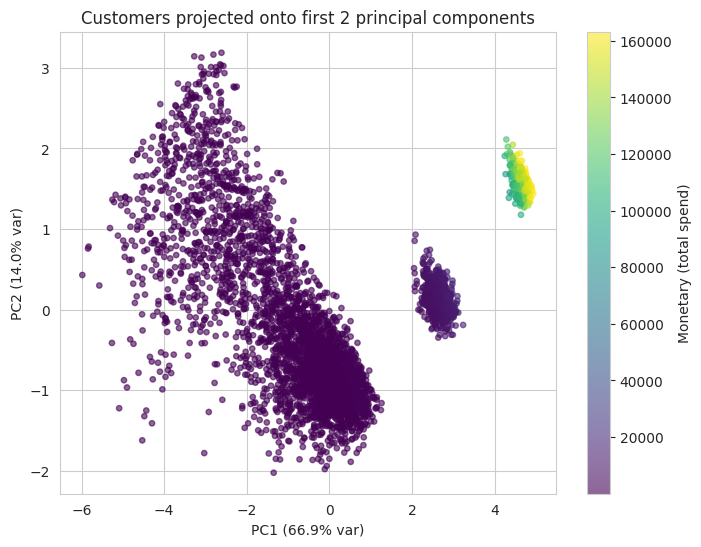

In [7]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=df["Monetary"], cmap="viridis", alpha=0.6, s=15)
plt.colorbar(sc, label="Monetary (total spend)")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)")
plt.title("Customers projected onto first 2 principal components")
plt.savefig("../reports/figures/03_pca_2d.png", dpi=120)
plt.show()

In [8]:
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=["PC1", "PC2"],
    index=FEATURE_COLUMNS
)
loadings.round(3)

,PC1,PC2
Recency,-0.296,0.555
Frequency,0.416,-0.063
Monetary,0.422,0.194
AvgBasketValue,0.374,0.441
AvgItemsPerBasket,0.370,0.456
UniqueProducts,0.404,-0.159
CancellationRate,0.030,-0.142
CustomerLifespanDays,0.348,-0.451


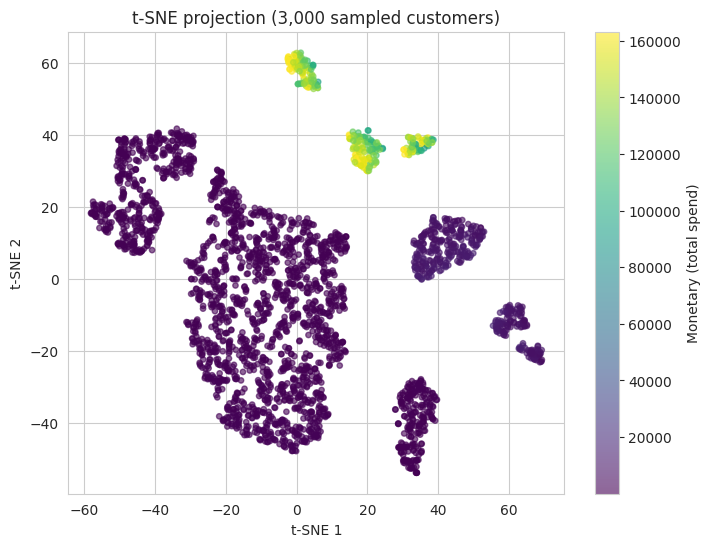

In [9]:
sample_size = min(3000, len(X_scaled))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_scaled), size=sample_size, replace=False)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_tsne = tsne.fit_transform(X_scaled[sample_idx])

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df["Monetary"].values[sample_idx], cmap="viridis", alpha=0.6, s=15)
plt.colorbar(sc, label="Monetary (total spend)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title(f"t-SNE projection ({sample_size:,} sampled customers)")
plt.savefig("../reports/figures/03_tsne_2d.png", dpi=120)
plt.show()

In [10]:
joblib.dump(scaler, "../models/scaler.joblib")
print("Scaler saved to models/scaler.joblib")

Scaler saved to models/scaler.joblib
